In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("tab10")
print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


In [7]:
print("⏳ Cargando datos... (puede tardar un minuto)")
df = pd.read_csv('../data/raw/MetroPT3(AirCompressor).csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])

df.set_index('timestamp', inplace=True)

# Eliminar la columna basura 
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"✅ Datos cargados listos para analizar. Total registros: {len(df):,}")

⏳ Cargando datos... (puede tardar un minuto)
✅ Datos cargados listos para analizar. Total registros: 1,516,948


In [8]:
df_hourly = df.resample('1h').mean()

fallas = [
    {'inicio': '2020-02-28', 'fin': '2020-03-01', 'nombre': 'Falla 1: Fuga Aire'},
    {'inicio': '2020-03-23', 'fin': '2020-03-23 23:59:59', 'nombre': 'Falla 2: Fuga Secador'},
    {'inicio': '2020-05-30', 'fin': '2020-06-02', 'nombre': 'Falla 3: Fuga Aceite'}
]

print("✅ Datos agrupados por hora y zonas de fallas definidas en 2020.")

✅ Datos agrupados por hora y zonas de fallas definidas en 2020.


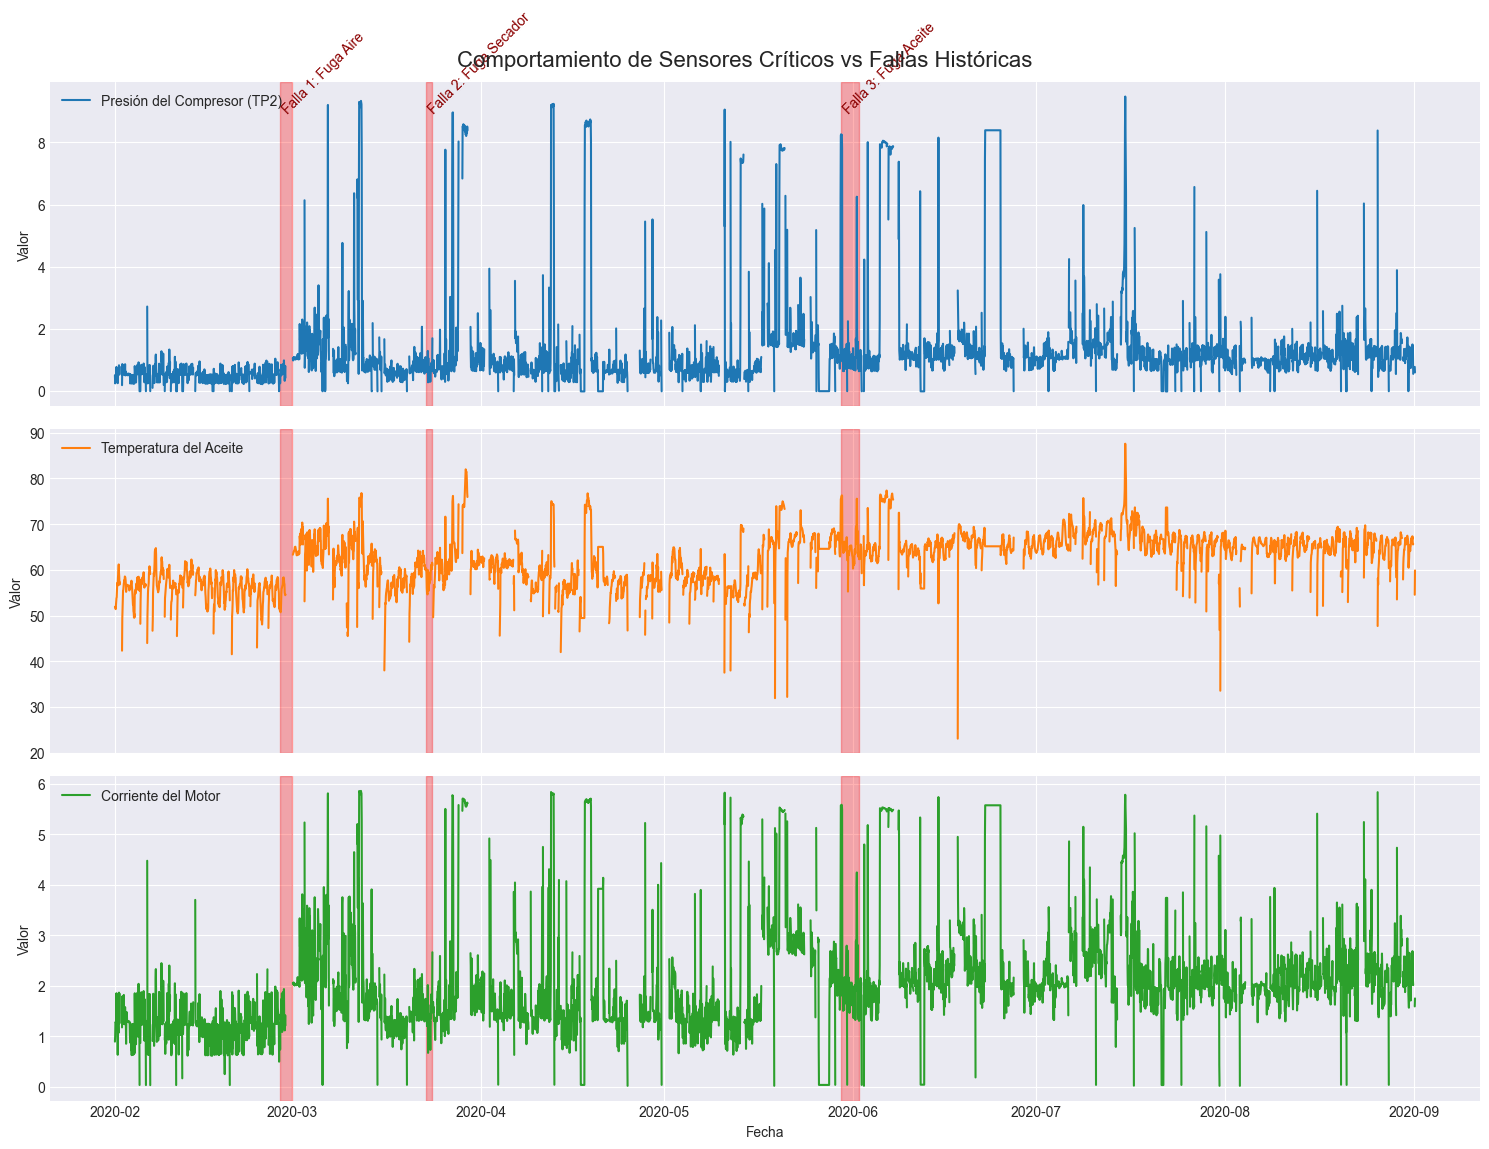

In [9]:
sensores_criticos = ['TP2', 'Oil_temperature', 'Motor_current']
nombres_espanol = ['Presión del Compresor (TP2)', 'Temperatura del Aceite', 'Corriente del Motor']

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle('Comportamiento de Sensores Críticos vs Fallas Históricas', fontsize=16, y=0.92)

for i, (sensor, nombre) in enumerate(zip(sensores_criticos, nombres_espanol)):
    axes[i].plot(df_hourly.index, df_hourly[sensor], label=nombre, color=sns.color_palette()[i])
    axes[i].set_ylabel('Valor')
    axes[i].legend(loc='upper left')
    

    for falla in fallas:
        axes[i].axvspan(pd.to_datetime(falla['inicio']), pd.to_datetime(falla['fin']), 
                        color='red', alpha=0.3)
        if i == 0: 
            axes[i].text(pd.to_datetime(falla['inicio']), axes[i].get_ylim()[1]*0.9, 
                         falla['nombre'], color='darkred', rotation=45)

plt.xlabel('Fecha')
plt.tight_layout()
plt.show()

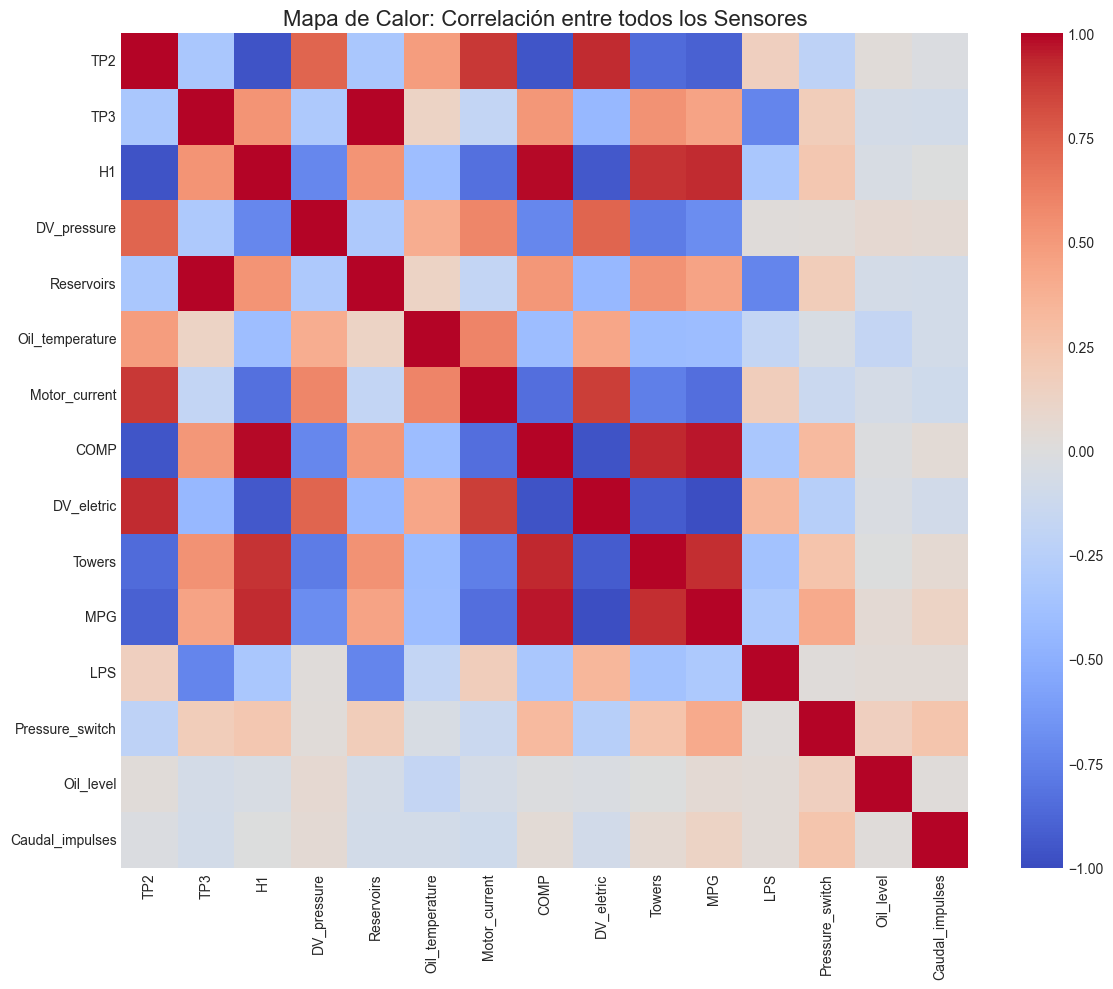

In [10]:
plt.figure(figsize=(12, 10))
correlacion = df_hourly.corr()

sns.heatmap(correlacion, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Mapa de Calor: Correlación entre todos los Sensores', fontsize=16)
plt.tight_layout()
plt.show()

### 📊 Análisis de Comportamiento Previo a las Fallas

Al observar la superposición de los datos históricos con las zonas críticas de falla (franjas rojas), podemos identificar patrones claros de **degradación progresiva**:

1. **Inestabilidad en la Presión (TP2):** Días antes de la *Falla 1* y *Falla 2* (que corresponden a fugas de aire), la señal de presión del compresor pierde su ciclo rítmico normal. Se observan caídas abruptas y picos irregulares, lo que indica que el sistema está perdiendo presión por una fuga y le cuesta estabilizarse.
2. **Esfuerzo del Motor:** Como consecuencia directa de la pérdida de aire, el motor se ve forzado a trabajar más tiempo y con mayor intensidad para intentar compensar la presión. Esto se refleja en comportamientos anómalos (picos o variaciones) en la **Corriente del Motor** y la **Temperatura del Aceite** en los periodos previos al colapso total.

**Conclusión:** Este comportamiento anómalo previo a la zona roja confirma que **las fallas no son repentinas, sino que tienen una degradación medible**. Esto garantiza que nuestro modelo predictivo de Machine Learning tendrá los patrones necesarios para aprender y generar alertas tempranas.